Stripe only uplink example
----------------------------
This notebook shows how to receive a CP-OFDM signal on the stripe and propagate it towards the central unit. All the radio units receive the signal and propagate it one by one where the furthest unit starts propagating first.

In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

from sub_THz_stripe.amplifier.amplifier import Amplifier
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.utils import calculate_sndr

In [2]:
# Read out the config file.
config_file = "examples/stripe_ul/config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

In [3]:
amp = Amplifier(max_out_amp=100)

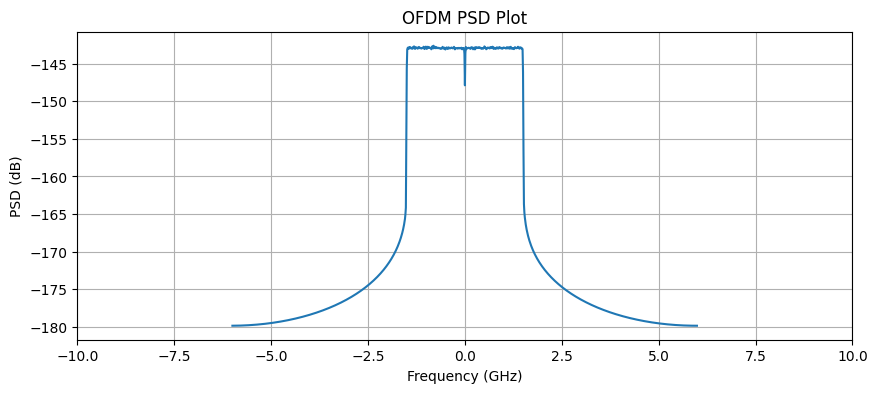

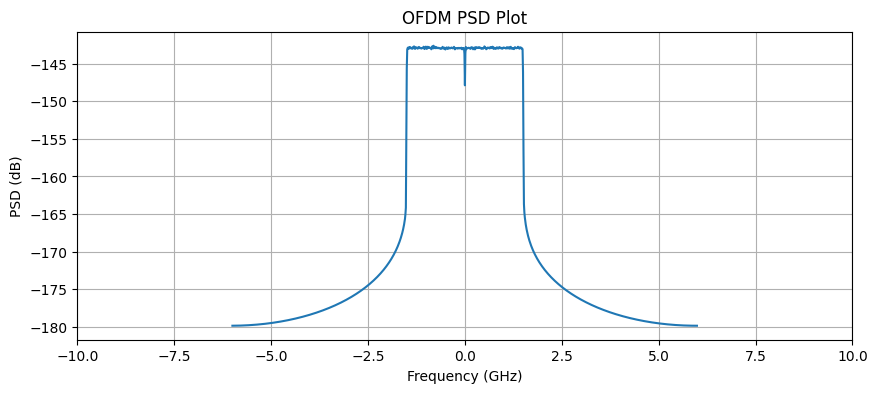

In [4]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)
wf.plot_psd()

In [5]:
amp.set_noise_var(273.15 + 25, 3000000000, 10)
y = amp.run(ofdm_time)
sndr = calculate_sndr(ofdm_time, y, wf)

print(sndr[0])
print(np.mean(sndr[0]))

amp.set_noise_var(273.15 + 25, 3000000000, 20)
y = amp.run(ofdm_time)
sndr = calculate_sndr(ofdm_time, y, wf)

print(sndr[0])
print(np.mean(sndr[0]))

[55.58270577 56.96319397 61.44432228 ... 57.53304143 57.63317876
 58.8128314 ]
57.6475315153195
[49.11271096 47.78798891 46.37616196 ... 47.04894478 48.8076409
 49.0840482 ]
47.63564564043516
